# Challenge 01: Image Enhancement


# Description

Image enhancement is a fundamental process in digital image processing that aims to improve the visual appearance of an image or to provide a better transform representation for future automated image processing. The goal of this challenge is to enhance the quality of a specific image by adjusting its brightness, contrast, and clarity through various spatial domain techniques, making it more suitable for human perception and analysis.

# Challenge

Apply different image enhancement techniques to improve image quality and visibility. Compare the results using techniques such as Gamma Correction, Global Histogram Equalization, and Contrast Limited Adaptive Histogram Equalization (CLAHE), in addition to Gaussian blurring as a preprocessing or smoothing step.

# Part i — Libraries:

cv2 (OpenCV): The primary library used for reading images, color space conversions (BGR to RGB/Gray), and implementing enhancement algorithms like Histogram Equalization and CLAHE.

numpy as np: Used for numerical operations, specifically for applying the power-law transformation in Gamma Correction.

matplotlib.pyplot as plt: Used for displaying the original and processed images in a comparative grid layout.

# Part ii — User-Defined Functions:

plot_image(image, title)
A helper function that wraps imshow, set_title, and axis('off'). This prevents code redundancy and ensures a consistent visual style when displaying multiple enhancement results in subplots.

# Part iii — Image Conversion:

cv2.COLOR_BGR2RGB: Since OpenCV loads images in BGR format by default, this conversion is necessary to ensure colors are displayed correctly (RGB) when using Matplotlib.

BGR to Individual Channels: For Histogram-based techniques, the image is often split into its three color channels to apply the enhancement to each channel independently before merging them back.

# Part iv — Image Preparation:

Before applying certain enhancements, Gaussian Blur is used as a smoothing technique. It helps in reducing high-frequency noise that might be amplified during contrast enhancement processes, ensuring that the final output looks natural and clear.

# Part v — Code Explanation:

# Part 1 — DIP Techniques Used:

    1. Gaussian Blur: A smoothing filter used to reduce image noise and detail. It works by convolving the image with a Gaussian kernel, which is effective for preparing the image for further processing.

    2. Gamma Correction: A non-linear operation used to encode and decode luminance. By applying the formula O=(I/255)γ×255, we can adjust the brightness of the image to recover details in dark or overexposed areas.

    3. Global Histogram Equalization: This technique improves contrast by spreading out the most frequent intensity values. It calculates the cumulative distribution function (CDF) to stretch the histogram across the entire range (0-255).

    4. CLAHE (Contrast Limited Adaptive Histogram Equalization): An advanced version of histogram equalization that operates on small regions (tiles) rather than the whole image. It limits contrast amplification to prevent noise over-amplification, making it ideal for local detail enhancement.

# Part 2 — Additional Methods:

cv2.split() & cv2.merge(): Used to separate the color channels for individual processing and combine them back after enhancement.

cv2.createCLAHE(): Initializes the CLAHE operator with specific parameters like clipLimit and tileGridSize.

np.array(..., dtype='uint8'): Ensures the pixel values remain within the valid 8-bit range (0-255) after mathematical transformations.

# Part 3 — Difficulty Faced:

The main challenge was balancing the contrast enhancement in CLAHE. Setting a high clipLimit resulted in unwanted noise in the background, while a very low limit didn't provide enough enhancement. After several trials, a clipLimit=2.0 was selected as it provided the best balance between clarity and natural appearance.

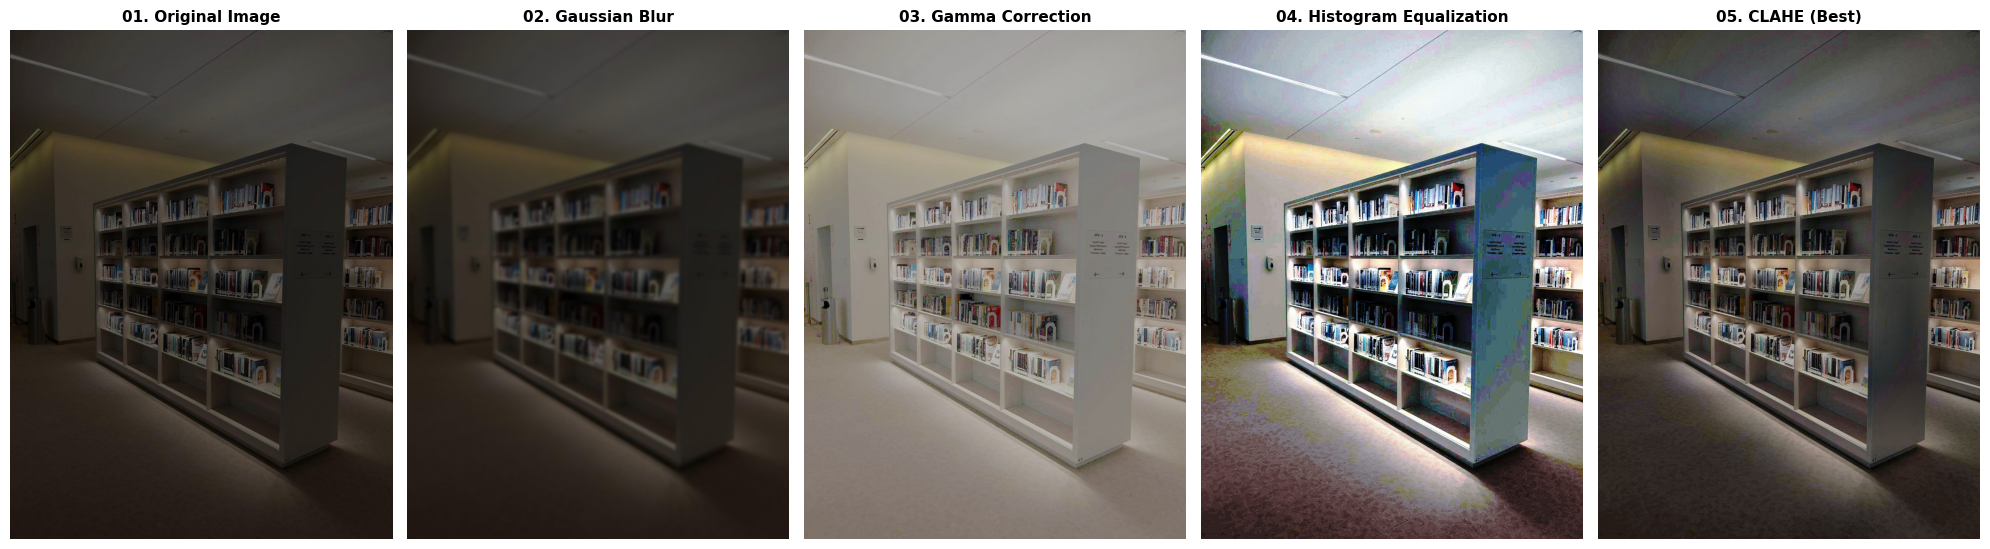

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the original image
image_bgr = cv2.imread("images/challenge_1.jpeg")
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# 2. Image Enhancement & Processing Techniques

# --- Gaussian Blur (Blurring/Smoothing) ---
# Considered the "worst" in terms of detail clarity as it removes edge information
image_blurred_bgr = cv2.GaussianBlur(image_bgr, (25, 25), 0)
image_blurred_rgb = cv2.cvtColor(image_blurred_bgr, cv2.COLOR_BGR2RGB)

# --- Gamma Correction (Brightness Adjustment) ---
# Improving visibility by adjusting pixel intensity
gamma = 3.0
image_gamma_correction = np.array(255 * (image_bgr / 255) ** (1.0 / gamma), dtype='uint8')
image_gamma_rgb = cv2.cvtColor(image_gamma_correction, cv2.COLOR_BGR2RGB)

# Split channels for contrast enhancement
channels = cv2.split(image_bgr)

# --- Global Histogram Equalization ---
# Enhancing contrast globally across the entire image
hist_channels = [cv2.equalizeHist(ch) for ch in channels]
hist_eq_rgb = cv2.cvtColor(cv2.merge(hist_channels), cv2.COLOR_BGR2RGB)

# --- CLAHE (Adaptive Histogram Equalization) ---
# The best result as it enhances local contrast while preserving details
# Updated parameters for maximum brightness and clarity
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
clahe_channels = [clahe.apply(ch) for ch in channels]
clahe_rgb = cv2.cvtColor(cv2.merge(clahe_channels), cv2.COLOR_BGR2RGB)

# 3. Visualization: Ordered from Original -> Worst Adjustment -> Best Enhancement
titles = ["01. Original Image", "02. Gaussian Blur", "03. Gamma Correction", "04. Histogram Equalization", "05. CLAHE (Best)"]
images = [image_rgb, image_blurred_rgb, image_gamma_rgb, hist_eq_rgb, clahe_rgb]

plt.figure(figsize=(20, 8))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[i])
    plt.title(titles[i], fontsize=11, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

# Part vi — Comparison of Techniques:

1. Gaussian Blur: Successfully reduced noise but made the image appear "soft" and lost some fine edge details, confirming its role as a smoothing rather than an enhancement tool.

2. Gamma Correction: Improved the overall brightness of the image, making it more visible, but it did not significantly improve the local contrast between different objects.

3. Global Histogram Equalization: Significantly increased the contrast, making the image much brighter. However, it caused some areas to look "washed out" because it applied the same transformation globally.

4. CLAHE: Produced the best and most professional result. It successfully enhanced local details and contrast without the "washed out" effect of global equalization, making the textures and objects in the image appear sharp and well-defined.